# Clustering de Gènes 

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 200)

from preprocess import prepare_hiseq, prepare_ecg
from utils import describe, plot_pca_2d

In [2]:
# internes
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
# externes
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

In [3]:
hiseq = prepare_hiseq()

X_raw = hiseq["X_raw"]
y = hiseq["y"].astype("category").cat.codes
X_scaled = hiseq["X_scaled"]
X_pca2d = hiseq["X_pca2d"]
X_pca100 = hiseq["X_pca100"]

In [4]:
describe(X_raw, "Gènes")

describe(y, "Classes Cancers")


=== Gènes ===
Shape : (801, 20264)
Nombre de NaN : 0
            gene_0    gene_1    gene_2    gene_3     gene_4  ...  gene_20526  gene_20527  gene_20528  gene_20529  gene_20530
Unnamed: 0                                                   ...                                                            
sample_0       0.0  2.017209  3.265527  5.478487  10.431999  ...   12.003135    9.650743    8.921326    5.286759         0.0
sample_1       0.0  0.592732  1.588421  7.586157   9.623011  ...   12.674552   10.517059    9.397854    2.094168         0.0
sample_2       0.0  3.511759  4.327199  6.881787   9.870730  ...    9.045255    9.788359   10.090470    1.683023         0.0
sample_3       0.0  3.663618  4.507649  6.659068  10.196184  ...   11.392682    9.694814    9.684365    3.292001         0.0
sample_4       0.0  2.655741  2.821547  6.539454   9.738265  ...   11.922439    9.217749    9.461191    5.110372         0.0

[5 rows x 20264 columns]

=== Classes Cancers ===
Shape : (801,)
Nombr

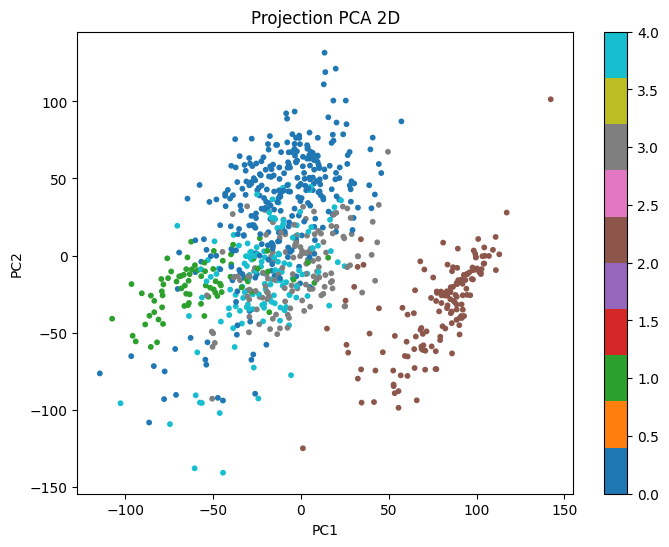

In [5]:
plot_pca_2d(X_pca2d, y)

## K-Means

### Introduction à la classe

In [20]:
from sklearn.cluster import KMeans

clusters = (
    KMeans(
        n_clusters=8, 
        init='k-means++', 
        n_init='auto', 
        max_iter=300, 
        tol=0.0001, 
        verbose=0, 
        random_state=None, 
        copy_x=True, 
        algorithm='lloyd'
    ).fit(X_raw)
)

print("Attributes :\n",
      "\n\ncluster_centers_ :\n", clusters.cluster_centers_,
      "\n\nlabels_ :\n", clusters.labels_[0:10], "..."
      "\n\nn_features_in_ :\n", clusters.n_features_in_,
      "\n\nn_iter_:\n", clusters.feature_names_in_,
      "\n\ninertia_:\n", clusters.feature_names_in_
)

Attributes :
 

cluster_centers_ :
 [[1.03348290e-02 3.18457021e+00 3.24901127e+00 ... 1.00028783e+01
  5.67287207e+00 2.28103284e-01]
 [4.68650615e-02 2.39455662e+00 2.44209827e+00 ... 9.43000135e+00
  5.12209056e+00 1.29488321e-01]
 [4.16794151e-02 3.39366420e+00 3.46483108e+00 ... 9.37095971e+00
  5.34327858e+00 1.98563795e-01]
 ...
 [2.25005092e-02 3.44083332e+00 3.23252914e+00 ... 9.35115207e+00
  3.60223280e+00 3.28232539e-02]
 [1.58267745e-02 3.66863412e+00 4.04546741e+00 ... 9.81183368e+00
  5.22038743e+00 3.25309363e-02]
 [2.98308365e-03 2.72163431e+00 2.62561807e+00 ... 9.75119231e+00
  5.30921839e+00 3.57272167e-02]] 

labels_ :
 [4 2 6 6 7 6 1 4 0 6] ...

n_features_in_ :
 20264 

n_iter_:
 ['gene_0' 'gene_1' 'gene_2' ... 'gene_20528' 'gene_20529' 'gene_20530'] 

inertia_:
 ['gene_0' 'gene_1' 'gene_2' ... 'gene_20528' 'gene_20529' 'gene_20530']


In [ ]:
from utils import metrics_clustering, print_metrics_table

m = metrics_clustering(
    labels=y,
    data=X_raw,
    method=KMeans,
    runs=10
)

print_metrics_table(m)
# temps en secondes
# mémoire en MiB

Model metrics:

      silhouette  davies_bouldin  calinski_harabasz  adjusted_rand     nmi    time      space
Mean      0.2229          1.8527           124.5189         0.9612  0.9493  0.5242  1184.8512
Std       0.0000          0.0000             0.0000         0.0000  0.0000  0.0353    17.1511




## DBSCAN

### Introduction à la classe

In [ ]:
from sklearn.cluster import DBSCAN

clusters = (
    DBSCAN(
        
    )
)

print("Attributes :\n",
      "\n\naffinity_matrix_ :\n", clusters.affinity_matrix_,
      "\n\nlabels_ :\n", clusters.labels_[0:10], "..."
      "\n\nn_features_in_ :\n", clusters.n_features_in_,
      "\n\nfeature_names_in_ :\n", clusters.feature_names_in_
)

In [ ]:
from utils import metrics_clustering, print_metrics_table

m = metrics_clustering(
    labels=y,
    data=X_raw,
    method=DBSCAN,
    runs=10
)

print_metrics_table(m)
# temps en secondes
# mémoire en MiB

Model metrics:

      silhouette  davies_bouldin  calinski_harabasz  adjusted_rand     nmi    time      space
Mean      0.2229          1.8527           124.5189         0.9612  0.9493  0.5242  1184.8512
Std       0.0000          0.0000             0.0000         0.0000  0.0000  0.0353    17.1511




## Spectral Clustering

### Introduction à la classe

In [6]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import pairwise_distances
D = pairwise_distances(X_raw)

K = 5 ; seed = 42
sigma = np.median(D)
gamma = 1 / (2 * sigma**2)


clusters = (
    SpectralClustering(
        n_clusters=K, # 5 cancers mentioned
        random_state=seed, # for our 10 run metrics
        affinity='rbf', # gaussian kernel similarity
        gamma=gamma, # bandwidth: high>1=decrease
        assign_labels='kmeans', # end of algorithm
        n_init=10, # k-means iterations
        verbose=False # debug
    ).fit(X_raw)
)


print("Attributes :\n",
      "\n\naffinity_matrix_ :\n", clusters.affinity_matrix_,
      "\n\nlabels_ :\n", clusters.labels_[0:10], "..."
      "\n\nn_features_in_ :\n", clusters.n_features_in_,
      "\n\nfeature_names_in_ :\n", clusters.feature_names_in_
)

Attributes :
 

affinity_matrix_ :
 [[1.         0.51606679 0.54847666 ... 0.54757278 0.80303922 0.75450574]
 [0.51606679 1.         0.53981315 ... 0.510558   0.57114086 0.64889343]
 [0.54847666 0.53981315 1.         ... 0.38899498 0.63695691 0.62400514]
 ...
 [0.54757278 0.510558   0.38899498 ... 1.         0.59416255 0.61566458]
 [0.80303922 0.57114086 0.63695691 ... 0.59416255 1.         0.79194924]
 [0.75450574 0.64889343 0.62400514 ... 0.61566458 0.79194924 1.        ]] 

labels_ :
 [3 0 3 3 1 3 2 3 1 3] ...

n_features_in_ :
 20264 

feature_names_in_ :
 ['gene_0' 'gene_1' 'gene_2' ... 'gene_20528' 'gene_20529' 'gene_20530']


In [7]:
np.bincount(clusters.labels_)

array([149, 298, 145, 136,  73])

In [8]:
np.bincount(y)

array([300,  78, 146, 141, 136])

## Mesure des métriques

In [ ]:
from utils import metrics_clustering, print_metrics_table

m = metrics_clustering(
    labels=y,
    data=X_raw,
    method=SpectralClustering,
    runs=10, 
    n_clusters=K, # 5 cancers mentioned
    affinity='rbf', # gaussian kernel similarity
    gamma=gamma, # bandwidth: high>1=decrease
    assign_labels='kmeans', # end of algorithm
    n_init=10, # k-means iterations
    verbose=False # debug
)

print_metrics_table(m)
# temps en secondes
# mémoire en MiB

Model metrics:

      silhouette  davies_bouldin  calinski_harabasz  adjusted_rand     nmi    time      space
Mean      0.2229          1.8527           124.5189         0.9612  0.9493  0.5242  1184.8512
Std       0.0000          0.0000             0.0000         0.0000  0.0000  0.0353    17.1511




# Détection d'anomalies sur signaux cardiaques

In [10]:
ecg = prepare_ecg()

X_raw_ecg = ecg["X_raw"]
y_ecg = ecg["y"]
X_pca2d_ecg = ecg["X_pca2d"]

describe(X_raw_ecg, "ECG : données brutes")



=== ECG : données brutes ===
Shape : (4998, 140)
Nombre de NaN : 0
        0         1         2         3         4    ...       135       136       137       138       139
0  0.565751  0.403325  0.174330  0.139541  0.132887  ...  0.636101  0.614525  0.619195  0.660354  0.465778
1  0.481247  0.292669  0.108637  0.117948  0.179900  ...  0.671159  0.644389  0.690859  0.679208  0.345032
2  0.526886  0.425440  0.161455  0.107276  0.157957  ...  0.521837  0.523069  0.640975  0.658310  0.420208
3  0.617307  0.489682  0.194544  0.143799  0.147247  ...  0.717773  0.706196  0.725345  0.706704  0.423042
4  0.643792  0.588088  0.352583  0.191373  0.137914  ...  0.756039  0.702608  0.712587  0.727213  0.556803

[5 rows x 140 columns]


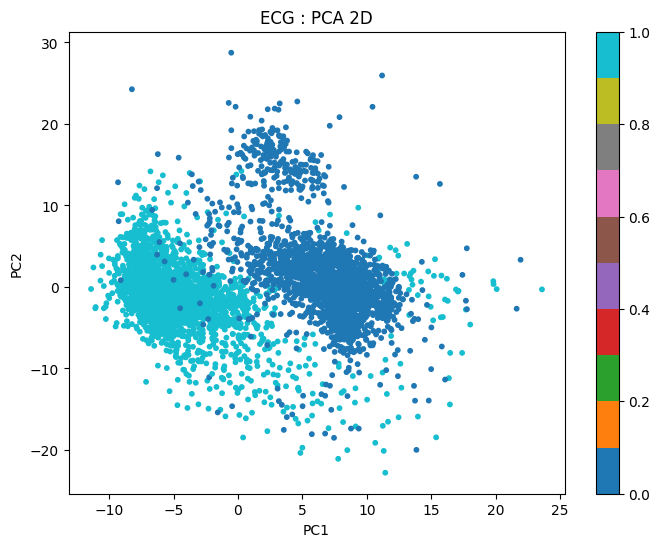

In [11]:
plot_pca_2d(X_pca2d_ecg, y_ecg, "ECG : PCA 2D")


In [12]:
# Séparation des classes
X = X_raw_ecg.astype(np.float32)
y = y_ecg.astype(np.int64)

X_normal = X[y == 0] # données normales
X_anomaly = X[y == 1] # données anormales (anomalies)

In [13]:
# Tailles exactes de chaque ensemble de données

# Tailles normales
n = len(X_normal)
n_train = int(0.6 * n)
n_test_normal = int(0.3 * n)
n_val_normal = n - n_train - n_test_normal

# Tailles anormales
m = len(X_anomaly)
m_test = int(0.8 * m)
m_val = m - m_test

In [14]:
# Mélange des données
X_normal = X_normal.sample(frac=1, random_state=42).reset_index(drop=True)
X_anomaly = X_anomaly.sample(frac=1, random_state=42).reset_index(drop=True)

# Coversion en numpy
X_normal = X_normal.to_numpy().astype(np.float32)
X_anomaly = X_anomaly.to_numpy().astype(np.float32)

# Création des ensembles d'entraînement, de test et de validation
X_train = X_normal[:n_train]
X_test = np.concatenate([X_normal[n_train:n_train + n_test_normal],
                    X_anomaly[:m_test]
])
y_test = np.concatenate([np.zeros(n_test_normal, dtype=np.int64), # normales
                     np.ones(m_test, dtype=np.int64)])            # anomalies
X_val = np.concatenate([X_normal[n_train + n_test_normal:],
                   X_anomaly[m_test:]
])
y_val = np.concatenate([np.zeros(n_val_normal, dtype=np.int64), # normales
                    np.ones(m_val, dtype=np.int64)])            # anomalies

In [15]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Conversion en tenseurs torch
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_test = torch.tensor(y_test, dtype=torch.int64)
y_val = torch.tensor(y_val, dtype=torch.int64)

data_dict = {
    "X_train": X_train,
    "X_test": X_test,
    "X_val": X_val,
    "y_test": y_test,
    "y_val": y_val
}

torch.save(data_dict, "ecg_data.pt")


In [16]:
# Application des algorithmes de détection d'anomalies
from train import train_deepAE, train_denoisingAE, train_isolation_forest, dataloaders
from utils import metrics_anomaly

loaders = dataloaders()

# Calcul des métriques et entrainement du modèle Isolation Forest
metrics_IF_1run = metrics_anomaly(train_isolation_forest, loaders["train"], loaders["val_IF"], loaders["test_IF"], runs=1)
metrics_IF_10run= metrics_anomaly(train_isolation_forest, loaders["train"], loaders["val_IF"], loaders["test_IF"], runs=10)
print_metrics_table(metrics_IF_1run, "Isolation Forest - 1 run")
print_metrics_table(metrics_IF_10run, "Isolation Forest - 10 runs")


# Calcul des métriques et entrainement du modèle Deep Autoencoder
metrics_DAE_1run = metrics_anomaly(train_deepAE, loaders["train"], loaders["val_loader"], loaders["test_loader"], y_test=y_test, runs=1)
metrics_DAE_10run= metrics_anomaly(train_deepAE, loaders["train"], loaders["val_loader"], loaders["test_loader"], y_test=y_test, runs=10)
print_metrics_table(metrics_DAE_1run, "Deep Auto-Encoder - 1 run")
print_metrics_table(metrics_DAE_10run, "Deep Auto-Encoder - 10 runs")

# Calcul des métriques et entrainement du modèle Denoising Autoencoder
metrics_DAE_1run = metrics_anomaly(train_denoisingAE, loaders["train"], loaders["val_loader"], loaders["test_loader"], y_test=y_test, runs=1)
metrics_DAE_10run= metrics_anomaly(train_denoisingAE, loaders["train"], loaders["val_loader"], loaders["test_loader"], y_test=y_test, runs=10)
print_metrics_table(metrics_DAE_1run, "Denoising Auto-Encoder - 1 run")
print_metrics_table(metrics_DAE_10run, "Denoising Auto-Encoder - 10 runs")

Isolation Forest - 1 run metrics:

      accuracy  recall  precision  f1_score  roc_auc  train_time  mem_usage_mb
Mean    0.2559  0.0668     0.8764    0.1242   0.9384      0.2901           0.0
Std     0.0000  0.0000     0.0000    0.0000   0.0000      0.0000           0.0


Isolation Forest - 10 runs metrics:

      accuracy  recall  precision  f1_score  roc_auc  train_time  mem_usage_mb
Mean    0.2559  0.0668     0.8764    0.1242   0.9384      0.2747           0.0
Std     0.0000  0.0000     0.0000    0.0000   0.0000      0.0127           0.0


Deep Auto-Encoder - 1 run metrics:

      accuracy  recall  precision  f1_score  roc_auc  train_time  mem_usage_mb
Mean    0.2637  0.0749     0.9067    0.1384   0.9522      2.2718        0.0903
Std     0.0000  0.0000     0.0000    0.0000   0.0000      0.0000        0.0000


Deep Auto-Encoder - 10 runs metrics:

      accuracy  recall  precision  f1_score  roc_auc  train_time  mem_usage_mb
Mean    0.2623  0.0731     0.9064    0.1352   0.9544      